<h1 align="center">GPR Testing</h1>

## **Pip Installs**

pip install matplotlib (3.10.7)

pip install numpy (2.3.5)

pip install scikit_learn(1.7.2)

pip install scipy(1.16.3)


In [1]:
# Install the requirements
%pip install matplotlib numpy scikit_learn scipy

Note: you may need to restart the kernel to use updated packages.


## About GPR Algorithm

Think of GPR as a "smart" interpolation method that uses Bayesian probability.
 Instead of fitting a rigid function like a polynomial, you define a kernel, which acts as a prior describing the expected properties of the function (e.g., "I expect this curve to be very smooth").
  The GPR then calculates the most probable function (the "posterior") that fits your observed data points, given those properties. The key benefit is that it doesn't just return a single "best-fit" line;
   it returns a full probability distribution, giving you the mean prediction and a confidence interval (variance) for how certain it is.

## Content of Notebook:

1) Function that Creates a signal(radio astronomy observation)

2) Function that Estimate the Hyperparameters that will be used as initial values for the GPR

3) Function that implement the GPR algorithm



## Import Libraries

In [2]:
from enum import Enum

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter

# We need GPR and Kernels from scikit-learn
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, Matern, WhiteKernel


## Create Signal(Background + Spectral line + Noise)

In [3]:

class SignalType(Enum):
    POLY=1
    SIN=2
    BOTH=3

def background_creation(freq : np.ndarray ) -> tuple :
    """
    Create a signal with bacground,spectral line and noise.The whole procedure will be random.

    Args:
        freq (np.ndarray): the frequencies of the signal

    Returns:
        tuple: the spectral line and the full observation
    """
    rng = np.random.default_rng()

    # --- 1)Background Signal Creation ---
    possible_signals = [SignalType.POLY,SignalType.SIN,SignalType.BOTH]
    signal_type = rng.choice(possible_signals)
    background = np.zeros(freq.shape)
    #  --- Creation of Baseline ---
    # is_polyonimal = True -> signal = a(frequencies - (freq1,freqn))^2 + b
    # is_sin = True -> signal = A* sin (ω  * (frequencies - (freq1,freqn)) + phase)
    # is_both = True -> signal = polyonimal + sin

    # Add the sin component if the signal is sin or has both sin and polyonimal compoonents
    if signal_type in (SignalType.SIN, SignalType.BOTH) :
        amplitude = rng.uniform(0.5 , 3)
        omega = 2 * np.pi * rng.uniform(low = 0.1 , high = 0.9)
        phase = rng.uniform(low = 0 , high = 2*np.pi)
        background += amplitude * np.sin(omega*(freq- (rng.uniform(np.min(freq) , np.max(freq))) ) + phase)

    #Add the poly component if the signal is poly or has both poly and sin components
    if signal_type in (SignalType.POLY , SignalType.BOTH):
        a = rng.uniform(low=-2 , high = 3)
        b = rng.uniform(low=3 , high = 7)
        background+= a * (freq-(rng.uniform(np.min(freq) , np.max(freq))))**2 + b

    # --- 2) Noise Creation ---
    noise = rng.normal(0.1 , 0.7 , freq.shape)

    # ---3) Spectral Line Creation ---
    # The spectral line will have a random mean between 1419.5 - 1421 MHz . random Amplitude between 2-8 and random standar deviation between 0.1 - 0.3
    # Spectra line formula: A * e^((x-m)^2 / 2sigma^2)
    mean = rng.uniform(1419.5 , 1421)
    sigma = rng.uniform(0.05 , 0.1)
    amplitude = rng.uniform(3 , 10)
    spectral_line = amplitude * np.exp(- ((freq-mean)**2) / (2 * sigma ** 2))

    return background,spectral_line,background + noise + spectral_line


## Estimate HyperParameters

In [4]:
def estimate_hyperparameters(signal: np.ndarray, dx : float) -> tuple :
    """
    Estimate The hyper parameters as close as we can so the GPR can have a good initial estimation.

    Args:
        signal (np.ndarray): The signal
        dx (float): the sampling step

    Returns:
        tuple: the hyper parameters
    """
     # --- Noise std Approach ---
    noise_guess = np.median(np.abs(np.diff(signal)))

    # --- Signal Variance Approach ---
    total_var = np.var(signal)
    signal_var = total_var - noise_guess**2

    # --- Length Scale Approach ---
    # Create the gaussian filter
    linewidth_bins = signal_var
    smoothing_linewidth = 5.0*linewidth_bins
    signal_smooth = gaussian_filter1d(signal,sigma=smoothing_linewidth)

    # center the signal so the autocorrelation is around 0
    y_centered = signal_smooth - np.mean(signal_smooth)
    corr = np.correlate(y_centered,y_centered,mode="full")

    # The result of the mode = full  is symetric.The point in the middle (size//2) is the Lag 0.We are intersted in the distance as we move forward(Lag >=0).
    corr = corr[corr.size//2:]

    # Normalize the data of the correlation with the lag 0 (corr[0]) because at lag 0 the signal completely identifies with itself and the value is the variance of the signal.
    # We want a coefficient from 0 to 1 therefore doing corr/=corr[0] we force the curve to start from 1
    corr /=corr[0]

    # we save the indexes that has correlation < 0.368
    one_e = 0.368
    below = np.where(corr<one_e)[0]


    if len(below)>0 :
        # We will define the interpolation boundaries

        idx2 = below[0] # The first point under the 0.368
        idx1 = idx2 - 1 # The last point over 0.368

        if idx1 < 0:
            #If the correlation was under 0.368 at the first step then the signal is almost just noise so we return the minimum possible length
            return noise_guess,signal_var,dx

        # Calculate the sub-pixel accuracy
        # The curve is a line between two points and we find where 0.368 is located in this line
        fraction = (corr[idx1]- 0.368/corr[idx1] - corr[idx2])

        #isx1 + fraction is the position of the length_scale in pixels
        return noise_guess , signal_var , (idx1+fraction)*dx

    # if the correlation was never below 0.368
    return noise_guess , signal_var , np.nan

## Implementation of the GPR Algorithm

We want to approximate the background and subtract it from the total observation to find the spectral line. So it is important to emphasize how we will handle the observation and specifically the spectral line.

One option is to mask the spectral line and train the GPR with the background data but this is near impossible for every different signal that will be as an input.

The method we will use is the Mixture of Kernel.

An observation consist of : $$y(x) = f_{bg}(x) + f_{line}(x) + \epsilon$$

So we define a background kernel where the length_scale_bounds will start from some units above the length scale.In this way we inform the algorithm that:

The background is prohibited to change faster than x times of the length_scale.

After we define a spectral kernel where the length_scale_bounds will be 0.5*length_scale - 2 *length_scale.In this way we inform the algorithm that:

If you see fast changes of the signal it is not the background but the spectral line

After we define and the noise kernel we will make a total kernel and train the algorithm.

From the algorithm we take the convariance matrix K. $K_{total} = K_{bg}(\theta_1) + K_{line}(\theta_2) + \sigma_n^2 I$.

From the total matrix we will export the spectral line convariance matrix and make another one GPR only with the spectral convariance matrix

In [5]:

def gpr_algorithm(freq : np.ndarray , signal : np.ndarray , noise_guess : float , signal_var : float , length_scale_est : float) -> np.ndarray :
    """
    Implement the GPR algorithm to find the background of the observation.

    Args:
        freq (np.ndarray): frequencies axes
        signal (np.ndarray): the observation
        noise_guess (float): the noise_level estimation
        signal_var (float): the signal varinace estimation
        length_scale_est (float): the length scale estimation

    Returns:
        np.ndarray: the background
    """
    # --- DEFINE THE KERNELS ---

    # 1) Background Kernel (Smooth)
    # Bounds : From 5x to 50 *.We we prevent the algorithm from being affected by the line
    # signal_var -> first estimation in the amplitude of the signal
    # length_scale -> for how many data points the data is relative
    #length_scale_bounds  -> let the optimizer try values according to the theory above
    background_kernel = ConstantKernel(constant_value=signal_var , constant_value_bounds=(1e-2,1e5)) * RBF(length_scale=5*length_scale_est , length_scale_bounds=(2*length_scale_est , 50 * length_scale_est))

    # 2) Line Kernel (Sharp)
    # Bounds : near the estimate of the length_scale because it is sharp and sudden so the relative data are small distances apart
    spectral_kernel = ConstantKernel(constant_value=signal_var , constant_value_bounds=(1e-2,1e5))*Matern(length_scale=length_scale_est,length_scale_bounds=(0.2*length_scale_est,5*length_scale_est) , nu=0.5)

    # 3) Noise kernel
    noise_kernel = WhiteKernel(noise_guess , noise_level_bounds=(noise_guess*0.5,noise_guess*2))

    # 4) Total Kernel is the sum of the kernels
    total_kernel = background_kernel + spectral_kernel + noise_kernel

    # --- Implementation of the GPR Algorithm ---
    gpr = GaussianProcessRegressor(kernel=total_kernel,optimizer="fmin_l_bfgs_b",n_restarts_optimizer=2)
    #restart =5 -> Give the optimizer 5 loops to find the best fit
    #alpha = 0 -> we have defined noise kernel so we dont need to add alpha
    gpr.fit(freq.reshape(-1,1) , signal)
    # --- Component Extraction ---

    #We isolate ONLY the optimized Spectral kernel.
    # gpr.kernel_ represents the sum. We need to extract the first component (k_bg).
    # In sklearn, composite kernels are stored in a tree structure.
    # Typically, it is k1 (bg,line)+ k2(noise). Pay attention to indexing depending on the structure.

    # !! print(gpr.kernel_) the RBF/Matern with the smaller length_scale is the spectral kernel

    # --- Define new GPR with the optimized spectral kernel
    # if k_bg + ... then gpr.kernel_.k1 is the background kernel and spectral line kernel so k1.k2 is the spectral kernel
    optimized_spectral_kernel = gpr.kernel_.k1.k2

    # --- Estimate the Line ---
    # Use the weigths(alpha) the algorithm learned from the data but estimate the spectral line using only the rules of smoothness of the optimized spectral kernel
    line = optimized_spectral_kernel(freq.reshape(-1,1)) @ gpr.alpha_

    return line   # noqa: RET504


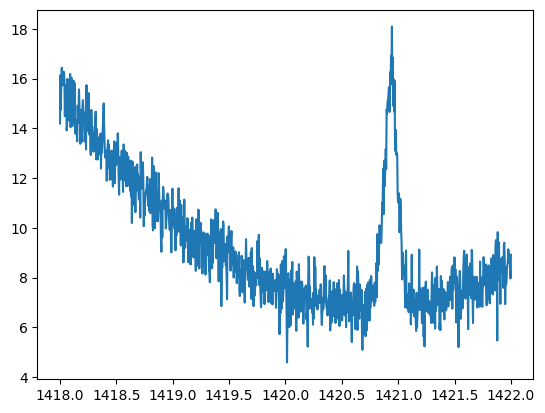

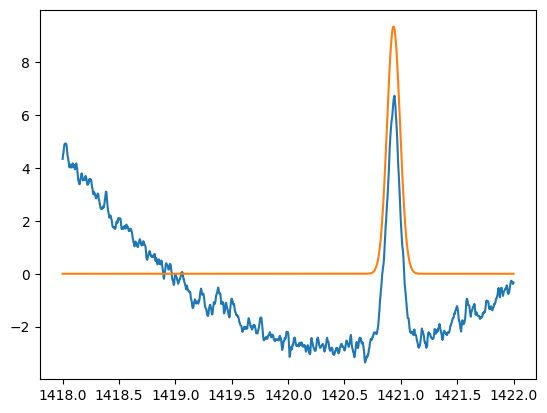

2.013226675770695


In [6]:
frequencies = np.linspace(1418,1422,1024)

res= []
for _i in range(1):
    background,true_line , signal = background_creation(frequencies)
    noise_guess , signal_var , length_scale = estimate_hyperparameters(signal,frequencies[1]-frequencies[0])
    estimated_line = gpr_algorithm(frequencies,signal,noise_guess,signal_var,length_scale)
    estimated_spectral_line =  estimated_line # signal -
    smooth_line = estimated_spectral_line
    res.append(np.abs(smooth_line-true_line))
    plt.plot(frequencies,signal)
    plt.show()
    plt.plot(frequencies,smooth_line)
    plt.plot(frequencies,true_line)
    plt.show()
res = np.array(res)
print(np.mean(res))


## Error Estimation

Summary of the Final Evaluation.

We will directly compare our "extracted line" (which we got from y_observed - gpr_baseline) against the "true line" (the ground truth). This allows us to precisely measure how successful our entire background removal process was.

Plots: We will visually check how well the two lines overlap and plot the "final error" (the difference between them).

Metrics (RMSE, $R^2$): We will calculate metrics to get a final score. The $R^2$ will tell us what percentage of the true line's shape we successfully recovered.